## PDF Derivation

Given two measurements from a log normal distribution with the same mean and $CV=\theta=\sigma/\mu$, the probability that the ratio $Y/X$ (where Y is the bigger of the two values) is larger than $k$ is given by the following equation.

$$ p(k) = 2P(Y/X \ge k) = 2\Phi \left[ \frac{-\log(k)}{\sqrt{2\log(\theta^{2} + 1)}} \right], \quad k > 1$$

We want to derive a PDF that we can utilize for maximum likelihood estimation. Thus, I will substitute $k=e^{x} : x > 0$ and look at the proper CDF of the distribution.

$$ p(x \le X) = 2P(Y/X \ge e^{x}) = 1-2\Phi \left[ \frac{-x}{\sqrt{2\log(\theta^{2} + 1)}} \right], \quad x > 0$$

Differentiating with respect to $x$ gives:

Let $s = \sqrt{2\log(\theta^{2} + 1)}$, so that $p(x \le X) = 1 - 2\Phi\left(\dfrac{-x}{s}\right)$. Using $\dfrac{d}{dz}\Phi(z) = \phi(z) = \dfrac{1}{\sqrt{2\pi}}e^{-z^{2}/2}$ and the chain rule:

$$ p(x) = \frac{d}{dx}\left[1 - 2\Phi\left(\frac{-x}{s}\right)\right] = -2\phi\left(\frac{-x}{s}\right)\cdot\left(-\frac{1}{s}\right) = \frac{2}{s}\phi\left(\frac{-x}{s}\right) $$

Since $\phi$ is an even function, $\phi(-x/s) = \phi(x/s)$, so:

$$ p(x) = \frac{2}{s}\cdot\frac{1}{\sqrt{2\pi}}\exp\left(-\frac{x^{2}}{2s^{2}}\right) = \frac{2}{s\sqrt{2\pi}}\exp\left(-\frac{x^{2}}{2s^{2}}\right) $$

Substituting back $s^{2} = 2\log(\theta^{2}+1)$:

$$ p(x) = \frac{1}{\sqrt{\pi \log(\theta^{2}+1)}} \exp\left(-\frac{x^{2}}{4\log(\theta^{2}+1)}\right), \quad x > 0 $$

This PDF can be calculated in numpy via the following code.

In [1]:
import numpy as np


def factor_pdf(fold_change, cv):
    """PDF of the fold change Y/X (larger over smaller) for two i.i.d. log-normal measurements with percent CV."""
    fold_change = np.asarray(fold_change)
    theta = cv / 100
    x = np.abs(np.log(fold_change))
    log_term = np.log(theta**2 + 1)
    return 1.0 / np.sqrt(np.pi * log_term) * np.exp(-(x**2) / (4 * log_term))


## Maximum Likelihood Estimation for theta

Since the PDF above is a half normal distribution with $\sigma^2 = 2\log(\theta^2 + 1)$, we can derive a maximum likelhood estimate for $\theta$. The general maximum likelihood estimate for $\sigma^2$ for a half normal is the following.

$$ \hat{\sigma}_{mle}^{2} = \frac{1}{N}\sum x_i^{2} $$ 

We have a 1-to-1 function from $\sigma^2$ to $\theta$, which is $\theta = f(\sigma^2) = \sqrt{\exp\left(\frac{1}{2}\sigma^2\right) - 1}$, so by the invariance of MLEs under transformation.

$$ \hat{\theta}_{mle} = \sqrt{\exp\left(\frac{1}{2}\hat{\sigma}_{mle}^2\right) - 1} = \sqrt{\exp\left(\frac{1}{2N}\sum_{i=1}^{N} x_i^{2}\right) - 1} $$

This can be calculated with the following numpy code.

In [2]:
def factor_mle(fold_change):
    """Maximum likelihood estimate of the percent CV from an array of fold changes (Y/X, larger over smaller)."""
    fold_change = np.asarray(fold_change)
    x = np.log(fold_change)
    theta = np.sqrt(np.exp(np.mean(x**2) / 2) - 1)
    return theta * 100

## Monte Carlo simulation to evaluate recovery

In the following section I will run a montecarlo simulation with 100 repetitions to see whether the above estimator truly works to derive the CV from paired data. For this, I will assume the mean of the underlying normal distribution is 10, which is fairly standard in proteomics. Then, I will cycle through a series of CVs from 2 to 20 as well as sample sizes of 10 and 100 to see the results for a range of plausible experiments.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
def simulate_samples(size, mean, cv):
    cv = cv / 100
    sigma = np.sqrt(np.log((cv**2) + 1))

    sample_1 = np.random.lognormal(mean = mean, sigma = sigma, size = size)
    sample_2 = np.random.lognormal(mean = mean, sigma = sigma, size = size)

    return sample_1, sample_2

def run_simulation(base_mean, random_effect_std, cv_sequence, size_sequence, repetitions):
    true_cv_list = []
    size_list = []
    classic_cv_list = []
    paired_cv_list = []
    for cv in cv_sequence:
        for size in size_sequence:
            for rep in range(repetitions):
                mean = base_mean + random_effect_std * np.random.normal(size = size)
                sample_1, sample_2 = simulate_samples(size, mean, cv)
                fold_change = np.maximum(sample_1, sample_2)/np.minimum(sample_1, sample_2)

                true_cv_list.append(cv)
                size_list.append(size)
                classic_cv_list.append( 100*(np.std(sample_1, ddof=1)/np.mean(sample_1)) )
                paired_cv_list.append( factor_mle(fold_change) )

    df = pd.DataFrame(
        dict(
            cv = true_cv_list,
            size = size_list,
            cv_est_classic = classic_cv_list,
            cv_est_paired = paired_cv_list
        )
    )

    return df

In [5]:
np.random.seed(0)
results = run_simulation(
    base_mean = 10,
    random_effect_std = 0,
    cv_sequence=np.arange(2, 21, 2),
    size_sequence=[10, 100],
    repetitions=100
)

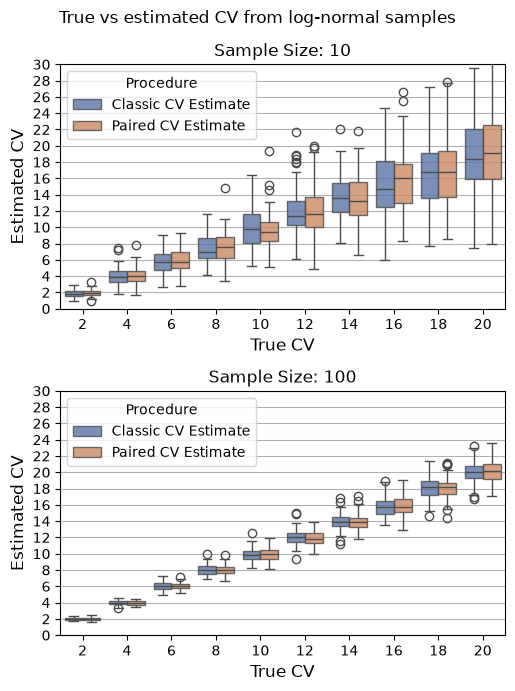

In [6]:
to_plot = results.melt(
    id_vars=["cv", "size"],
    var_name="statistic"
).join(
    pd.Series(
        ["Classic CV Estimate", "Paired CV Estimate"],
        index = ["cv_est_classic", "cv_est_paired"],
        name = "Procedure"
    ),
    on = "statistic"
)

g = sns.FacetGrid(
    to_plot, 
    row="size",
    height = 3.5,
    aspect = 1.5,
    sharex = False,
    despine = False
)

sns.boxplot(
    x = "cv",
    y = "value",
    hue = "Procedure",
    palette = "deep",
    dodge = True,
    data = to_plot[to_plot["size"] == 10],
    boxprops=dict(alpha=.8),
    ax = g.axes[0][0]
)

sns.boxplot(
    x = "cv",
    y = "value",
    hue = "Procedure",
    palette = "deep",
    dodge = True,
    data = to_plot[to_plot["size"] == 100],
    boxprops=dict(alpha=.8),
    ax = g.axes[1][0]
)

plt.yticks(np.arange(0, 32, 2))
plt.ylim(0, 30)
g.axes[0][0].grid(axis = "y")
g.axes[1][0].grid(axis = "y")

[g.axes[i][0].set_xlabel("True CV", fontsize = 12) for i in range(2)]
[g.axes[i][0].set_ylabel("Estimated CV", fontsize = 12) for i in range(2)]

g.set_titles(row_template="Sample Size: {row_name}", size = 12)
g.fig.suptitle("True vs estimated CV from log-normal samples", fontsize=12)
g.fig.subplots_adjust(top=0.9)

plt.tight_layout()
plt.savefig("../results/2026_09_15_factor_distribution/cv_estimate_simulation_no_random_effect.svg")
plt.show()

From the small sample size simulation, it appears that both estimators slightly underestimate the CV at higher CVs. However, this effect is attentuated well at higher sample sizes since both esimators are consistent. Furthermore, 100 samples isn't extraordinally high for a proteomics study, and can likely easily be accomodated in many designs.

Where this difference in esimators really matters however is when there is a random effect on the underlying distribution that add a secondary variance component. Here, the classic CV estimate won't be able to account for what portion of the CV is coming from the random effect and what portion is coming from the technical variation.

In [7]:
np.random.seed(0)
results = run_simulation(
    base_mean = 10,
    random_effect_std = 0.1,
    cv_sequence=np.arange(2, 21, 2),
    size_sequence=[10, 100],
    repetitions=100
)

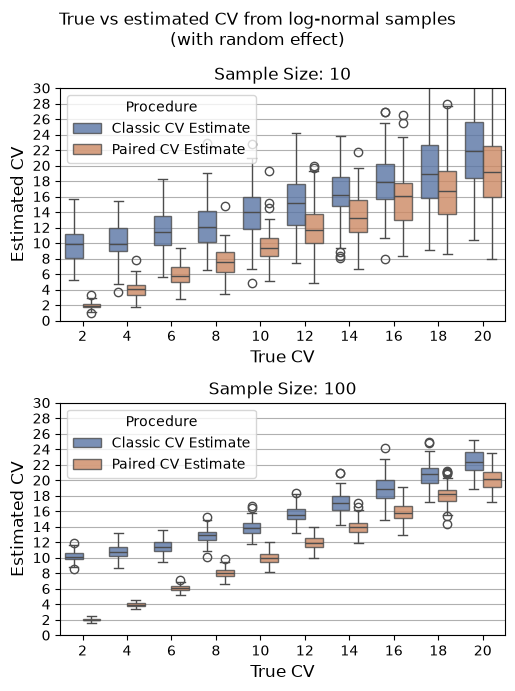

In [8]:
to_plot = results.melt(
    id_vars=["cv", "size"],
    var_name="statistic"
).join(
    pd.Series(
        ["Classic CV Estimate", "Paired CV Estimate"],
        index = ["cv_est_classic", "cv_est_paired"],
        name = "Procedure"
    ),
    on = "statistic"
)

g = sns.FacetGrid(
    to_plot, 
    row="size",
    height = 3.5,
    aspect = 1.5,
    sharex = False,
    despine = False
)

sns.boxplot(
    x = "cv",
    y = "value",
    hue = "Procedure",
    palette = "deep",
    dodge = True,
    data = to_plot[to_plot["size"] == 10],
    boxprops=dict(alpha=.8),
    ax = g.axes[0][0]
)

sns.boxplot(
    x = "cv",
    y = "value",
    hue = "Procedure",
    palette = "deep",
    dodge = True,
    data = to_plot[to_plot["size"] == 100],
    boxprops=dict(alpha=.8),
    ax = g.axes[1][0]
)

plt.yticks(np.arange(0, 32, 2))
plt.ylim(0, 30)
g.axes[0][0].grid(axis = "y")
g.axes[1][0].grid(axis = "y")

[g.axes[i][0].set_xlabel("True CV", fontsize = 12) for i in range(2)]
[g.axes[i][0].set_ylabel("Estimated CV", fontsize = 12) for i in range(2)]

g.set_titles(row_template="Sample Size: {row_name}", size = 12)
g.fig.suptitle("True vs estimated CV from log-normal samples\n(with random effect)", fontsize=12)
g.fig.subplots_adjust(top=0.9)

plt.tight_layout()
plt.savefig("../results/2026_09_15_factor_distribution/cv_estimate_simulation_with_random_effect.svg")
plt.show()

In the above plots, the extra variance is very minor with a standard deviation of 0.1 in the underlying normal distribution, but only the paired estimator recovers the technical CV.